In [1]:
import kaggle
from pathlib import Path

DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    "teejmahal20/airline-passenger-satisfaction",
    path=DATA_DIR,
    unzip=True,
)

print("Pobrane pliki:")
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name}")

Dataset URL: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
Pobrane pliki:
  test.csv
  train.csv


In [2]:
import sys
sys.path.append("..")

from src.preprocessing import (
    load_data,
    analyze_missing_values,
    impute_and_clean_data,
    build_preprocessing_pipeline,
    plot_correlation_matrix,
    plot_target_correlation,
    engineer_features,
    split_X_y,
)

In [3]:
train, test = load_data()

print("=== Train ===")
print(train.shape)
train.head()

=== Train ===
(103904, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
print("=== Braki w train ===")
analyze_missing_values(train)

print("\n=== Braki w test ===")
analyze_missing_values(test)

=== Braki w train ===
                          count  percent
Arrival Delay in Minutes    310      0.3

=== Braki w test ===
                          count  percent
Arrival Delay in Minutes     83     0.32


In [5]:
train_clean = impute_and_clean_data(train)
test_clean = impute_and_clean_data(test)

print("Train po czyszczeniu:", train_clean.shape)
print("Test po czyszczeniu: ", test_clean.shape)

Train po czyszczeniu: (103904, 23)
Test po czyszczeniu:  (25976, 23)


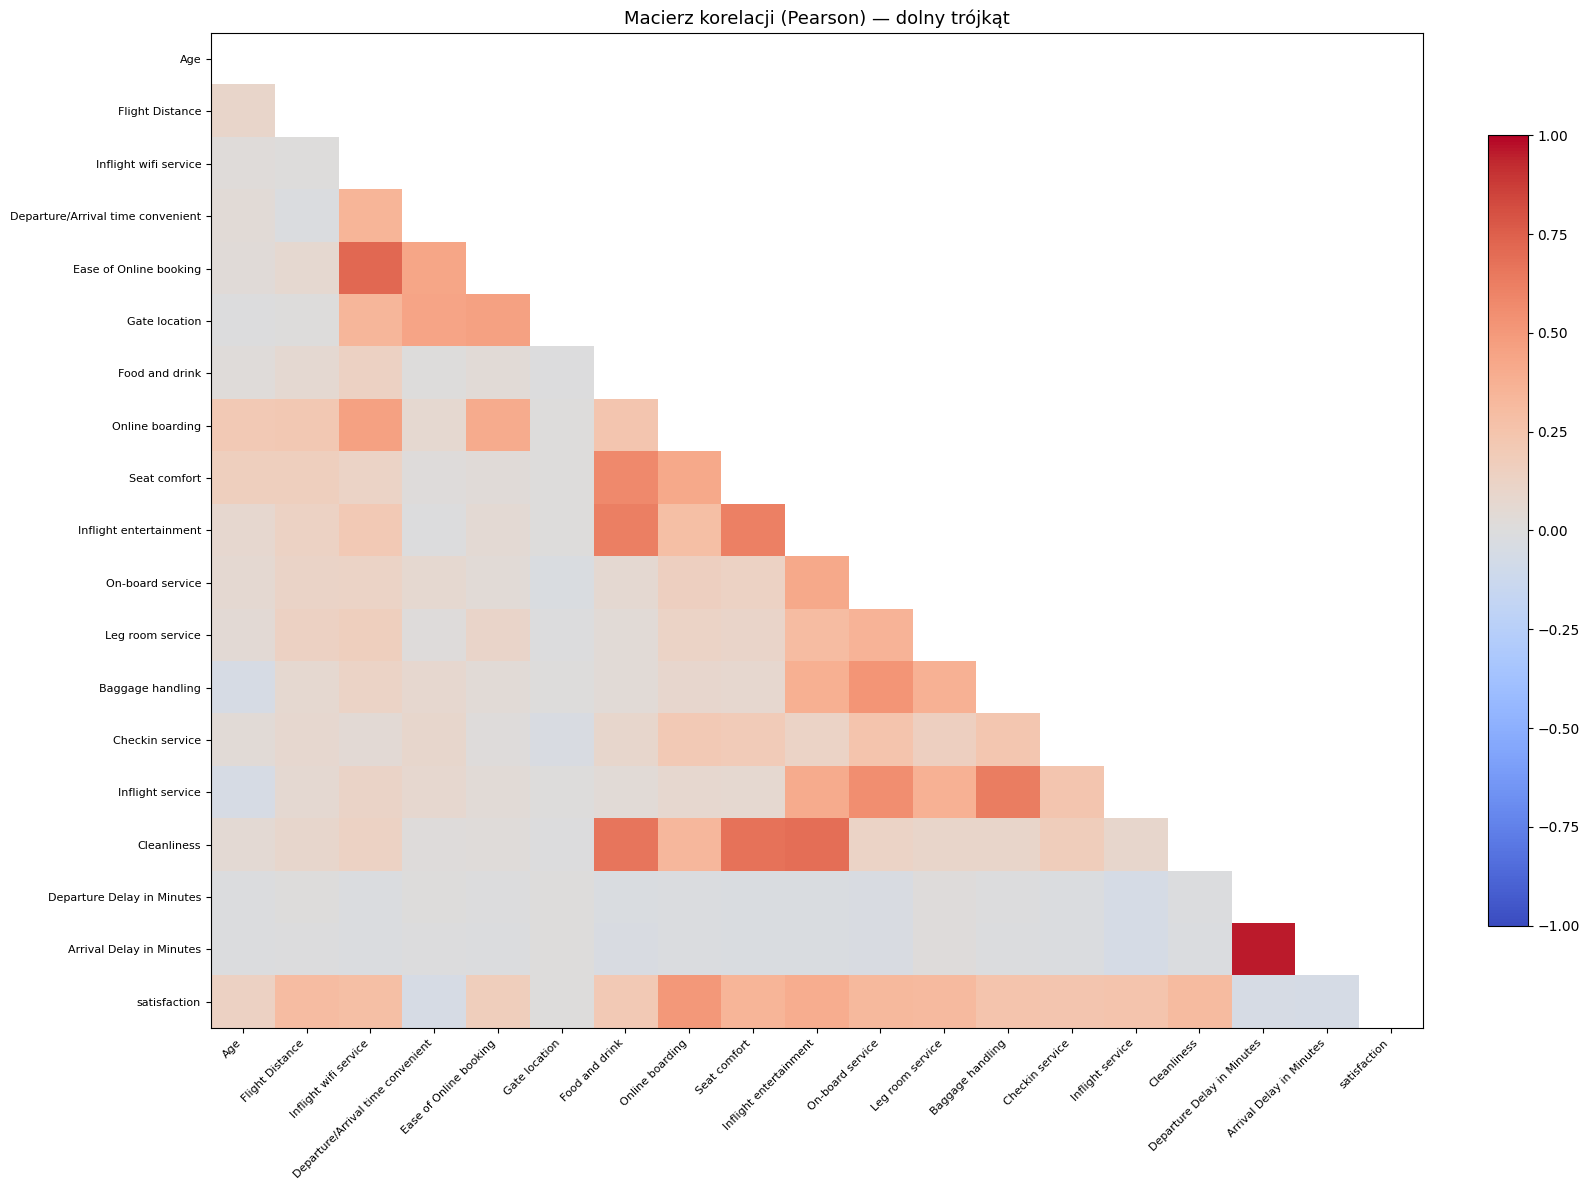

In [6]:
plot_correlation_matrix(train_clean)

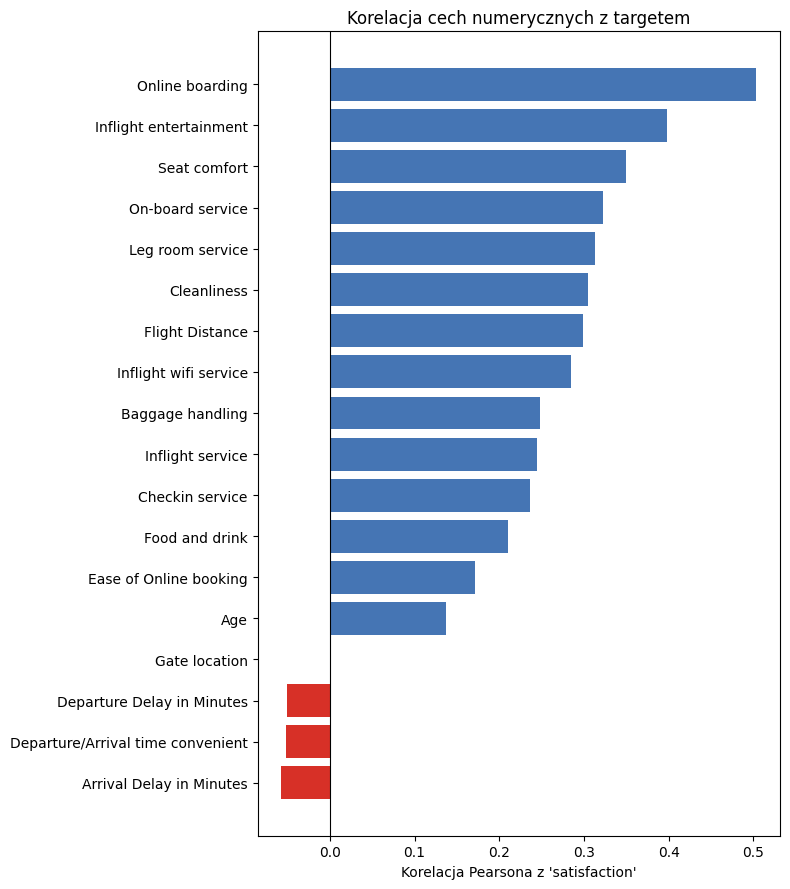

In [7]:
plot_target_correlation(train_clean)

In [8]:
train_feat = engineer_features(train_clean)
test_feat = engineer_features(test_clean)

print("Nowe kolumny:", [c for c in train_feat.columns if c not in train_clean.columns])
train_feat[["Departure Delay in Minutes", "Arrival Delay in Minutes", "total_delay", "avg_service_score"]].describe()

Nowe kolumny: ['total_delay', 'avg_service_score']


,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay,avg_service_score
count,103904.000000,103904.000000,103904.000000,103904.000000
mean,14.815618,15.133392,29.949011,3.261020
std,38.230901,38.649776,76.112807,0.687624
min,0.000000,0.000000,0.000000,0.846154
25%,0.000000,0.000000,0.000000,2.769231
50%,0.000000,0.000000,2.000000,3.307692
75%,12.000000,13.000000,24.000000,3.769231
max,1592.000000,1584.000000,3176.000000,5.000000


In [9]:
X_train, y_train = split_X_y(train_feat)
X_test, y_test = split_X_y(test_feat)

pipeline = build_preprocessing_pipeline(X_train)
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

print("X_train shape po transformacji:", X_train_transformed.shape)
print("X_test shape po transformacji: ", X_test_transformed.shape)
print("Rozkład klas y_train:\n", y_train.value_counts())

X_train shape po transformacji: (103904, 29)
X_test shape po transformacji:  (25976, 29)
Rozkład klas y_train:
 satisfaction
0    58879
1    45025
Name: count, dtype: int64
